# ARIA - LITE

ARIA Lite is a lightweight GraphRAG-based biomedical research assistant focused on breast cancer AI literature.

The project combines two retrieval paradigms:

1. Semantic Retrieval
   Dense vector embeddings are used to retrieve papers semantically related to a user query.

2. Graph-Based Retrieval
   Biomedical entities such as genes and drugs are extracted from papers and represented as relationships in a lightweight knowledge graph.

By combining these two approaches, the system aims to provide more grounded and explainable retrieval compared to traditional vector-only RAG systems.

The project is intentionally scoped for rapid iteration and learning:
- ~300-500 PubMed papers
- Abstract-only corpus
- Lightweight graph construction
- Citation-grounded responses

Core technologies:
- PubMed / Entrez API
- SciSpacy
- Sentence Transformers
- FAISS
- Python + Google Colab

End Goal:
Build a small but functional biomedical GraphRAG system capable of retrieving relevant breast cancer AI papers and generating grounded answers with PMID citations.

# 4_graph_builder.ipynb

PURPOSE:
Build a unified biomedical knowledge graph from PubMed papers.

This graph supports:
1. Paper → Entity relationships (core knowledge extraction)
2. Entity ↔ Entity co-occurrence (concept relationships)
3. Paper ↔ Paper similarity (semantic retrieval, V2 feature)

This is the core graph layer for ARIA-Lite.
V1 is a subset of this system (without paper-paper edges).


In [1]:
# ============================================================
# SECTION 1 — Install Libraries
# ============================================================

!pip install networkx

In [2]:
# ============================================================
# SECTION 2 — Imports
# ============================================================

from google.colab import drive
import os
import json
import networkx as nx
from collections import defaultdict
from tqdm import tqdm
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
# ============================================================
# SECTION 3 — Graph Configuration
# ============================================================

GRAPH_CONFIG = {
    "enable_paper_similarity": True,   # V2 feature toggle
    "min_entity_overlap": 1,           # threshold for linking papers
}

In [4]:
# ============================================================
# SECTION 4 — Project Paths and data loading
# ============================================================

drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/Colab_Notebooks/LLMs/ARIA_Lite"

PAPER_FILE_PATH = os.path.join(PROJECT_ROOT, "data", "processed", "clean_papers.json")
ENTITY_FILE_PATH = os.path.join(PROJECT_ROOT, "data", "processed", "clean_papers_with_entities.json")

with open(PAPER_FILE_PATH, "r") as f:
    papers = json.load(f)

with open(ENTITY_FILE_PATH, "r") as f:
    entities = json.load(f)

print(f"Papers loaded: {len(papers)}")
print(f"Entity records loaded: {len(entities)}")

Mounted at /content/drive
Papers loaded: 475
Entity records loaded: 474


In [5]:
# ============================================================
# SECTION 5 — Normalize Helper
# ============================================================

def normalize(text):
    return text.lower().strip()

In [6]:
# ============================================================
# SECTION 6 — Build Paper → Entity Mapping
# ============================================================

paper_to_entities = {}

for pmid, ent_list in entities.items():

    seen = set()
    clean_entities = set()

    for item in ent_list:

        entity = item.get("entity", "")
        label = item.get("label", "")

        entity = normalize(entity)

        # skip empty
        if not entity:
            continue

        # deduplicate per paper
        if entity in seen:
            continue

        seen.add(entity)
        clean_entities.add(entity)

    paper_to_entities[pmid] = list(clean_entities)

print("Paper → Entity mapping built (deduplicated)")

Paper → Entity mapping built (deduplicated)


In [7]:
# ============================================================
# SECTION 7 — Initialize Graph and Add Paper Nodes
# ============================================================

G = nx.Graph()

for paper in papers:
    G.add_node(
        paper["pmid"],
        type="paper",
        title=paper["title"]
    )

In [8]:
# ============================================================
# SECTION 8 — Add Entity Nodes + Paper → Entity Edge
# ============================================================

for pmid, ents in paper_to_entities.items():

    for ent in ents:

        # entity node
        G.add_node(ent, type="entity")

        # edge: paper → entity
        G.add_edge(
            pmid,
            ent,
            type="MENTIONS"
        )

In [ ]:
# ============================================================
# SECTION 9 — Entity ↔ Entity Co-occurrence Graph
# ============================================================

entity_graph = defaultdict(int)

for ents in paper_to_entities.values():

    ents = list(set(ents))

    for i in range(len(ents)):
        for j in range(i + 1, len(ents)):

            a, b = sorted([ents[i], ents[j]])
            entity_graph[(a, b)] += 1

max_w = max(entity_graph.values())

for (a, b), w in entity_graph.items():
    G.add_edge(
        a,
        b,
        type="CO_OCCURS",
        weight=w / max_w
    )

In [10]:
# ============================================================
# SECTION 10 — Paper ↔ Paper Similarity
# ============================================================

# Step 1 - Build text corpus
pmid_list = []
corpus = []

for p in papers:
    pmid = p["pmid"]

    text = p["text"]

    pmid_list.append(pmid)
    corpus.append(text)


# Step 2 - TF-IDF similarity
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(corpus)

similarity_matrix = cosine_similarity(X)

# Step 3 - Add edges
n = len(pmid_list)

for i in range(n):
    for j in range(i + 1, n):

        sim = similarity_matrix[i][j]

        if sim > 0.2:   # threshold

            G.add_edge(
                pmid_list[i],
                pmid_list[j],
                type="SIMILAR_PAPER",
                weight=float(sim)
            )

In [11]:
# ============================================================
# SECTION 11 — Graph Summary (ENHANCED)
# ============================================================

from collections import defaultdict

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# -----------------------------
# Edge type breakdown
# -----------------------------
edge_types = defaultdict(int)

for _, _, data in G.edges(data=True):
    edge_types[data.get("type", "UNKNOWN")] += 1

print("\nEdge types:")
for k, v in edge_types.items():
    print(k, v)

# -----------------------------
# Node type breakdown (NEW)
# -----------------------------
node_types = defaultdict(int)

for node, data in G.nodes(data=True):
    node_types[data.get("type", "UNKNOWN")] += 1

print("\nNode types:")
for k, v in node_types.items():
    print(k, v)

Nodes: 1108
Edges: 19839

Edge types:
MENTIONS 4814
SIMILAR_PAPER 1984
CO_OCCURS 13041

Node types:
paper 475
entity 633


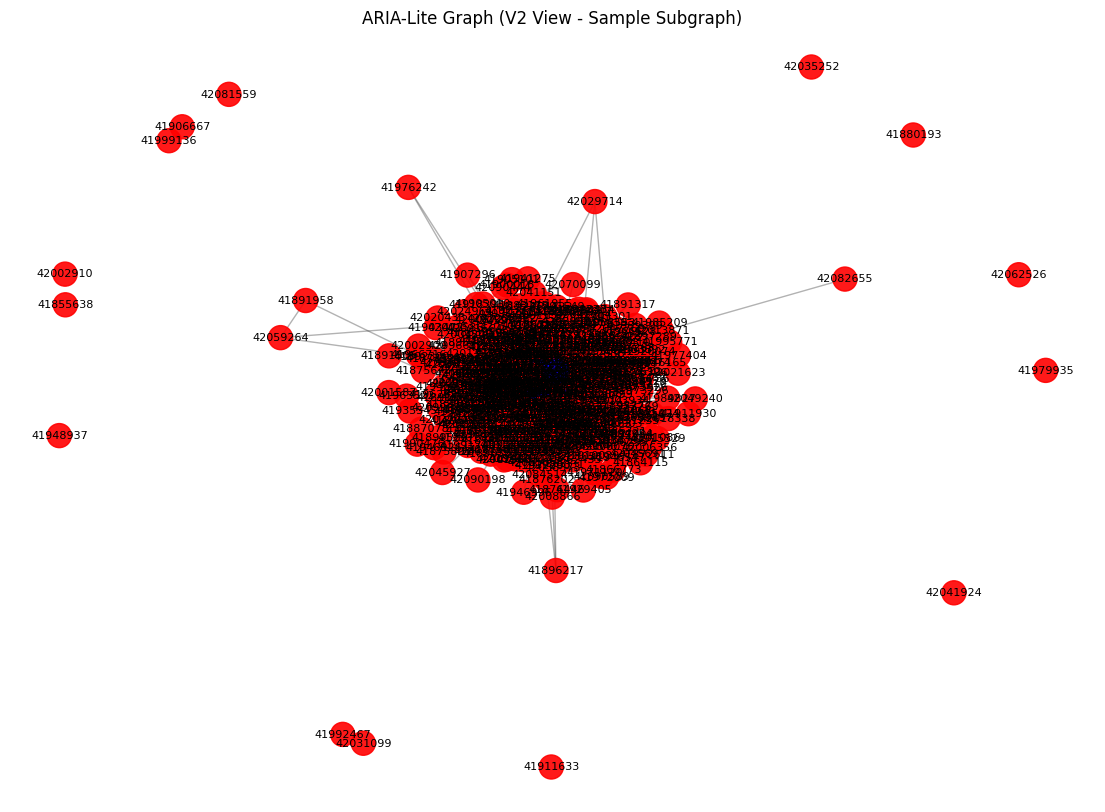

In [12]:
# ============================================================
# SECTION 12 - GRAPH VISUALIZATION (SANITY CHECK)
# ============================================================

import matplotlib.pyplot as plt
import networkx as nx

# -----------------------------
# Step 1: Sample subgraph (important for readability)
# -----------------------------
sample_nodes = list(G.nodes())[:500]  # adjust size if needed
subG = G.subgraph(sample_nodes)

# -----------------------------
# Step 2: Assign node colors
# -----------------------------
node_colors = []

for n in subG.nodes():
    node_type = subG.nodes[n].get("type", "unknown")

    if node_type == "paper":
        node_colors.append("red")
    elif node_type == "entity":
        node_colors.append("blue")
    else:
        node_colors.append("gray")

# -----------------------------
# Step 3: Layout
# -----------------------------
pos = nx.spring_layout(subG, seed=42, k=0.6)

# -----------------------------
# Step 4: Draw graph
# -----------------------------
plt.figure(figsize=(14, 10))

# Nodes
nx.draw_networkx_nodes(
    subG,
    pos,
    node_color=node_colors,
    node_size=300,
    alpha=0.9
)

# Edges
nx.draw_networkx_edges(
    subG,
    pos,
    alpha=0.3,
 width=1.0
)

# Labels (only for small graphs — otherwise messy)
nx.draw_networkx_labels(
    subG,
    pos,
    font_size=8
)

# -----------------------------
# Step 5: Title + display
# -----------------------------
plt.title("ARIA-Lite Graph (V2 View - Sample Subgraph)")
plt.axis("off")
plt.show()

In [13]:
# ============================================================
# SECTION 13 — Save Graph (FIXED)
# ============================================================

import os
import pickle

PROJECT_ROOT = "/content/drive/MyDrive/Colab_Notebooks/LLMs/ARIA_Lite"
GRAPH_FILE_PATH = os.path.join(PROJECT_ROOT, "data", "processed", "aria_lite_graph_v2.pkl")

# Ensure directory exists
os.makedirs(os.path.dirname(GRAPH_FILE_PATH), exist_ok=True)

# Save graph using pickle
with open(GRAPH_FILE_PATH, "wb") as f:
    pickle.dump(G, f)

print("Graph saved successfully at:", GRAPH_FILE_PATH)

Graph saved successfully at: /content/drive/MyDrive/Colab_Notebooks/LLMs/ARIA_Lite/data/processed/aria_lite_graph_v2.pkl
